In [1]:
import yfinance as yf
import pandas as pd
import numpy as np
import plotly.express as px
import plotly.graph_objects as go
from scipy.optimize import minimize

In [2]:
tickers = ['HDFCBANK.NS', 'RELIANCE.NS', 'INFY.NS', 'ICICIBANK.NS', 'ITC.NS']
benchmark = '^NSEI'  # Nifty 50

raw_data = yf.download(tickers + [benchmark], period='5y')
prices = raw_data['Close'].dropna()

returns = prices.pct_change().dropna()

[*********************100%***********************]  6 of 6 completed


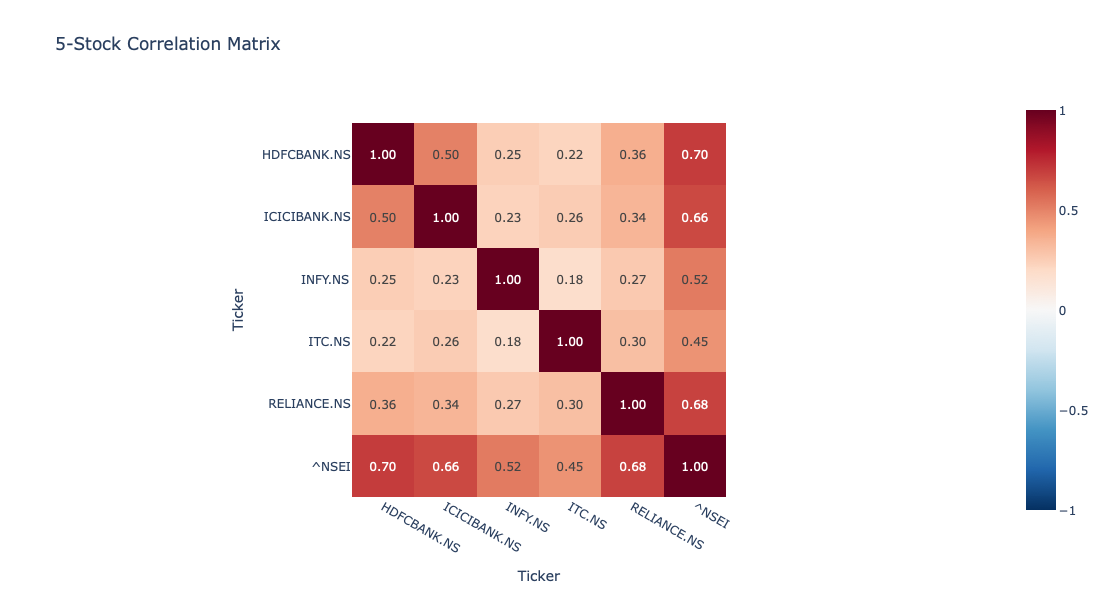

In [3]:
corr_matrix = returns.corr()

fig = px.imshow(
    corr_matrix,
    text_auto='.2f',
    color_continuous_scale='RdBu_r',
    zmin=-1, zmax=1,
    title='5-Stock Correlation Matrix'
)
fig.update_layout(width=600, height=600)
fig.show()

In [4]:
def risk_report(returns_data, risk_free_rate=0.065, confidence_level=0.95):
    """
    Generic risk report. Works on a single return series or a DataFrame
    with multiple assets/portfolios as columns.

    Parameters:
        returns_data: pd.Series or pd.DataFrame of daily returns
        risk_free_rate: annual risk-free rate (default 6.5%)
        confidence_level: VaR confidence level (default 95%)

    Returns:
        pd.DataFrame — one row per asset/portfolio, one column per metric
    """
    if isinstance(returns_data, pd.Series):
        returns_data = returns_data.to_frame()

    results = {}
    for col in returns_data.columns:
        r = returns_data[col].dropna()

        ann_return = r.mean() * 252
        ann_vol = r.std() * np.sqrt(252)
        sharpe = (ann_return - risk_free_rate) / ann_vol

        cumulative = (1 + r).cumprod()
        running_max = cumulative.cummax()
        drawdown = (cumulative - running_max) / running_max
        max_dd = drawdown.min()

        var_hist = np.percentile(r, (1 - confidence_level) * 100)

        results[col] = {
            'Annualized Return': ann_return,
            'Annualized Volatility': ann_vol,
            'Sharpe Ratio': sharpe,
            'Max Drawdown': max_dd,
            f'Historical VaR ({int(confidence_level*100)}%)': var_hist
        }

    return pd.DataFrame(results).T

In [5]:
report = risk_report(returns)
print(report.round(4))

              Annualized Return  Annualized Volatility  Sharpe Ratio  \
HDFCBANK.NS              0.0479                 0.2085       -0.0818   
ICICIBANK.NS             0.1857                 0.2036        0.5926   
INFY.NS                 -0.0235                 0.2532       -0.3495   
ITC.NS                   0.1420                 0.2000        0.3849   
RELIANCE.NS              0.0901                 0.2234        0.1125   
^NSEI                    0.0952                 0.1380        0.2188   

              Max Drawdown  Historical VaR (95%)  
HDFCBANK.NS        -0.2778               -0.0196  
ICICIBANK.NS       -0.2233               -0.0183  
INFY.NS            -0.4586               -0.0254  
ITC.NS             -0.4030               -0.0180  
RELIANCE.NS        -0.2718               -0.0212  
^NSEI              -0.1723               -0.0138  


In [6]:
cov_matrix = returns[tickers].cov() * 252  # annualized covariance
mean_returns = returns[tickers].mean() * 252  # annualized mean returns

In [7]:
n_assets = len(tickers)
weights_equal = np.array([1/n_assets] * n_assets)

In [8]:
def portfolio_variance(weights, cov_matrix):
    return weights.T @ cov_matrix @ weights

constraints = {'type': 'eq', 'fun': lambda w: np.sum(w) - 1}
bounds = tuple((0, 0.5) for _ in range(n_assets))  # same 50% cap as Week 2
initial_guess = np.array([1/n_assets] * n_assets)

result_defensive = minimize(
    portfolio_variance,
    initial_guess,
    args=(cov_matrix,),
    method='SLSQP',
    bounds=bounds,
    constraints=constraints
)

weights_defensive = result_defensive.x

In [9]:
corr_matrix_subset = returns[tickers].corr()

avg_corr = (corr_matrix_subset.sum() - 1) / (n_assets - 1)  # exclude self-correlation
inverse_corr = 1 / avg_corr
weights_decorr = inverse_corr / inverse_corr.sum()  # normalize to sum to 1

weights_decorr = weights_decorr.values

In [10]:
print(pd.Series(weights_decorr, index=tickers).round(3))

HDFCBANK.NS     0.169
RELIANCE.NS     0.178
INFY.NS         0.246
ICICIBANK.NS    0.171
ITC.NS          0.236
dtype: float64


In [11]:
portfolio_returns = pd.DataFrame({
    'Equal Weight': returns[tickers] @ weights_equal,
    'Defensive': returns[tickers] @ weights_defensive,
    'Decorrelation': returns[tickers] @ weights_decorr
})

In [12]:
combined = pd.concat([returns[tickers], portfolio_returns], axis=1)
full_report = risk_report(combined)
print(full_report.round(4))

               Annualized Return  Annualized Volatility  Sharpe Ratio  \
HDFCBANK.NS               0.0479                 0.2085       -0.0818   
RELIANCE.NS               0.0901                 0.2234        0.1125   
INFY.NS                  -0.0235                 0.2532       -0.3495   
ICICIBANK.NS              0.1857                 0.2036        0.5926   
ITC.NS                    0.1420                 0.2000        0.3849   
Equal Weight              0.0884                 0.1430        0.1639   
Defensive                 0.1007                 0.1406        0.2536   
Decorrelation             0.0836                 0.1433        0.1295   

               Max Drawdown  Historical VaR (95%)  
HDFCBANK.NS         -0.2778               -0.0196  
RELIANCE.NS         -0.2718               -0.0212  
INFY.NS             -0.4586               -0.0254  
ICICIBANK.NS        -0.2233               -0.0183  
ITC.NS              -0.4030               -0.0180  
Equal Weight        -0.2164   

              Equal Weight  Defensive  Decorrelation
HDFCBANK.NS            0.2      0.184          0.169
RELIANCE.NS            0.2      0.137          0.178
INFY.NS                0.2      0.156          0.246
ICICIBANK.NS           0.2      0.206          0.171
ITC.NS                 0.2      0.316          0.236


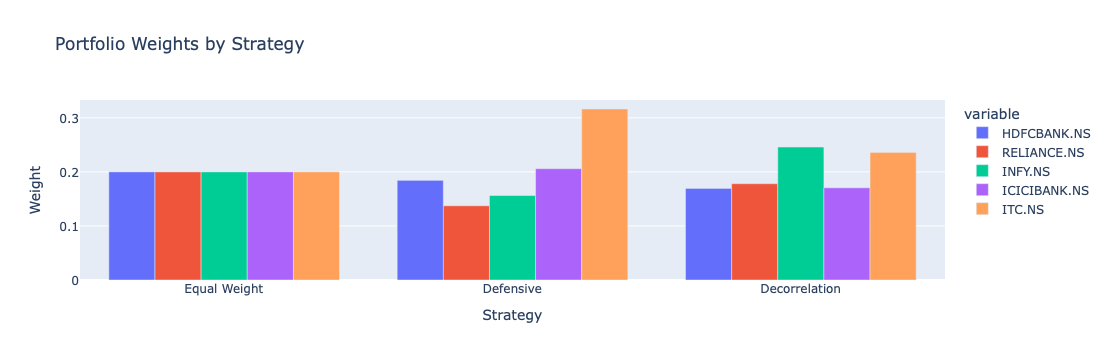

In [13]:
weights_all = pd.DataFrame({
    'Equal Weight': weights_equal,
    'Defensive': weights_defensive,
    'Decorrelation': weights_decorr
}, index=tickers)

print(weights_all.round(3))

fig_weights = px.bar(
    weights_all.T,
    barmode='group',
    title='Portfolio Weights by Strategy',
    labels={'value': 'Weight', 'index': 'Strategy'}
)
fig_weights.show() 


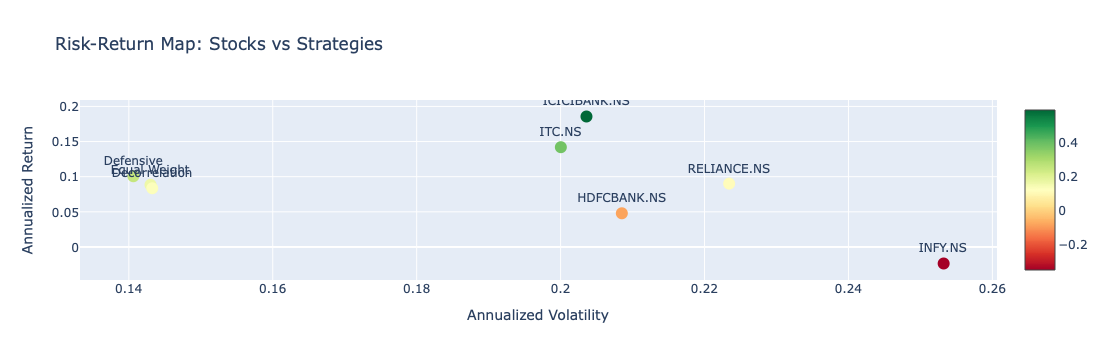

In [14]:
fig_scatter = go.Figure()
fig_scatter.add_trace(go.Scatter(
    x=full_report['Annualized Volatility'],
    y=full_report['Annualized Return'],
    mode='markers+text',
    text=full_report.index,
    textposition='top center',
    marker=dict(size=12, color=full_report['Sharpe Ratio'], colorscale='RdYlGn', showscale=True)
))
fig_scatter.update_layout(
    title='Risk-Return Map: Stocks vs Strategies',
    xaxis_title='Annualized Volatility',
    yaxis_title='Annualized Return'
)
fig_scatter.show()